# SEAS5 trigger individual regions
<!-- markdownlint-disable MD013 -->
Triggering in regions independently (only Centre-Nord and Sahel, for regional fund).

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import calendar

import pandas as pd
import numpy as np
import ocha_stratus as stratus
import matplotlib.pyplot as plt

from src.constants import *
from src.utils import rp_calc

## Load data

In [3]:
engine = stratus.get_engine("prod")
pcodes = ADM1_AOI_PCODES

In [4]:
query = f"""
SELECT *
FROM public.polygon
WHERE pcode IN {tuple(pcodes)}
"""
df_adm = pd.read_sql(query, engine)

In [5]:
query = f"""
SELECT *
FROM public.seas5
WHERE pcode in {tuple(pcodes)}
"""
df_seas5 = pd.read_sql(
    query, engine, parse_dates=["valid_date", "issued_date"]
)

In [6]:
df_seas5 = df_seas5.merge(df_adm)

In [7]:
df_seas5["name"].unique()

array(['Sahel', 'Centre-Nord'], dtype=object)

In [37]:
names_str = ", ".join(df_seas5["name"].unique())

## Plot seasonality

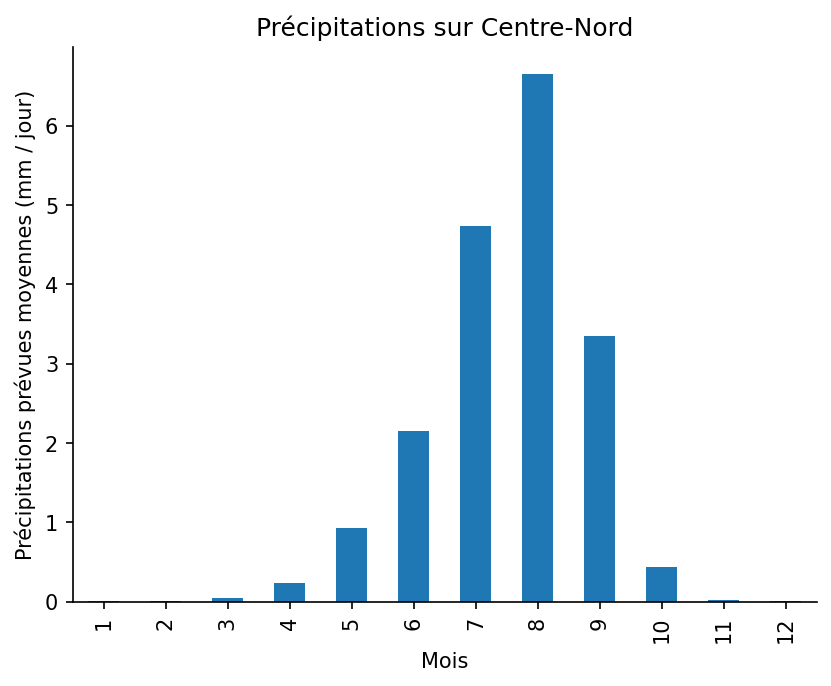

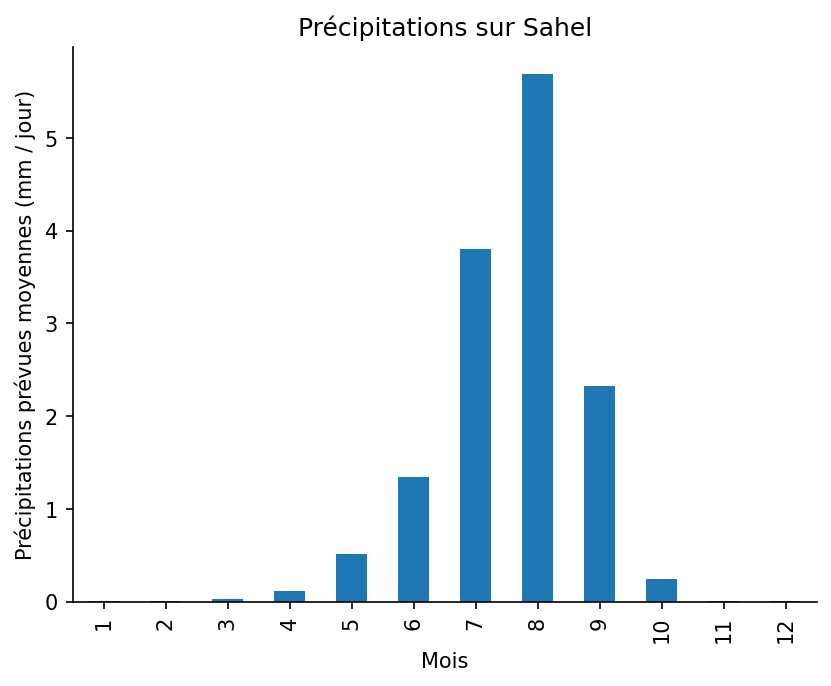

In [9]:
for name, group in df_seas5.groupby("name"):
    fig, ax = plt.subplots(dpi=150)

    group.groupby(group["valid_date"].dt.month)["mean"].mean().plot.bar(ax=ax)

    ax.set_xlabel("Mois")
    ax.set_ylabel("Précipitations prévues moyennes (mm / jour)")
    ax.set_title(f"Précipitations sur {name}")

    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)

Looks like JAS is suitable for them all.

In [10]:
season_months = [7, 8, 9]

In [15]:
df_seas5_grouped = (
    df_seas5.groupby(["name", "pcode", "valid_date", "issued_date"])["mean"]
    .mean()
    .reset_index()
)

In [16]:
df_seas5_grouped

,name,pcode,valid_date,issued_date,mean
0,Centre-Nord,BF49,1981-01-01,1981-01-01,0.000001
1,Centre-Nord,BF49,1981-02-01,1981-01-01,0.009939
2,Centre-Nord,BF49,1981-02-01,1981-02-01,0.016945
3,Centre-Nord,BF49,1981-03-01,1981-01-01,0.030899
4,Centre-Nord,BF49,1981-03-01,1981-02-01,0.053917
...,...,...,...,...,...
7485,Sahel,BF56,2025-11-01,2025-06-01,0.000625
7486,Sahel,BF56,2025-11-01,2025-07-01,0.019887
7487,Sahel,BF56,2025-12-01,2025-06-01,0.000528
7488,Sahel,BF56,2025-12-01,2025-07-01,0.000216


In [19]:
df_seas5_season = df_seas5_grouped[
    (df_seas5_grouped["valid_date"] == df_seas5_grouped["issued_date"])
    & (df_seas5_grouped["valid_date"].dt.month.isin(season_months))
    & (df_seas5_grouped["valid_date"].dt.year < 2025)
].copy()
df_seas5_season["year"] = df_seas5_season["valid_date"].dt.year
df_seas5_season["month"] = df_seas5_season["valid_date"].dt.month
df_seas5_season = df_seas5_season.drop(columns=["valid_date", "issued_date"])

In [20]:
df_seas5_season

,name,pcode,mean,year,month
27,Centre-Nord,BF49,6.251247,1981,7
34,Centre-Nord,BF49,6.283750,1981,8
41,Centre-Nord,BF49,3.957468,1981,9
111,Centre-Nord,BF49,5.245843,1982,7
118,Centre-Nord,BF49,5.159693,1982,8
...,...,...,...,...,...
7307,Sahel,BF56,7.767340,2023,8
7314,Sahel,BF56,4.188578,2023,9
7384,Sahel,BF56,5.228094,2024,7
7391,Sahel,BF56,8.579402,2024,8


In [21]:
df_seas5_season = rp_calc.calculate_groups_rp(
    df_seas5_season, by=["pcode", "month"], ascending=False
)

In [33]:
df_seas5_season

,pcode,month,name,mean,year,mean_rank,mean_rp
0,BF49,7,Centre-Nord,6.251247,1981,10.0,4.500000
1,BF49,7,Centre-Nord,5.245843,1982,29.0,1.551724
2,BF49,7,Centre-Nord,5.060226,1983,33.0,1.363636
3,BF49,7,Centre-Nord,5.749690,1984,21.0,2.142857
4,BF49,7,Centre-Nord,6.339271,1985,9.0,5.000000
...,...,...,...,...,...,...,...
259,BF56,9,Sahel,4.727531,2020,4.0,11.250000
260,BF56,9,Sahel,2.350689,2021,40.0,1.125000
261,BF56,9,Sahel,4.043296,2022,12.0,3.750000
262,BF56,9,Sahel,4.188578,2023,9.0,5.000000


In [143]:
total_years = df_seas5_season["year"].nunique()

## Plot thresholds and historical values

Specify the per-region, per-month return period, and use this to get the per-region, per-month thresholds.

Plot which historical years would have activated for each month, in each region.

In [170]:
rp_ind = 3

Text(0.5, 0.95, 'Précipitations sur Sahel, Centre-Nord, moyenne sur toute la zone, prévues avec délai de 0 mois\nPériode de retour par mois, par région = 3.0 ans; Période de retour globale = 1.6 ans')

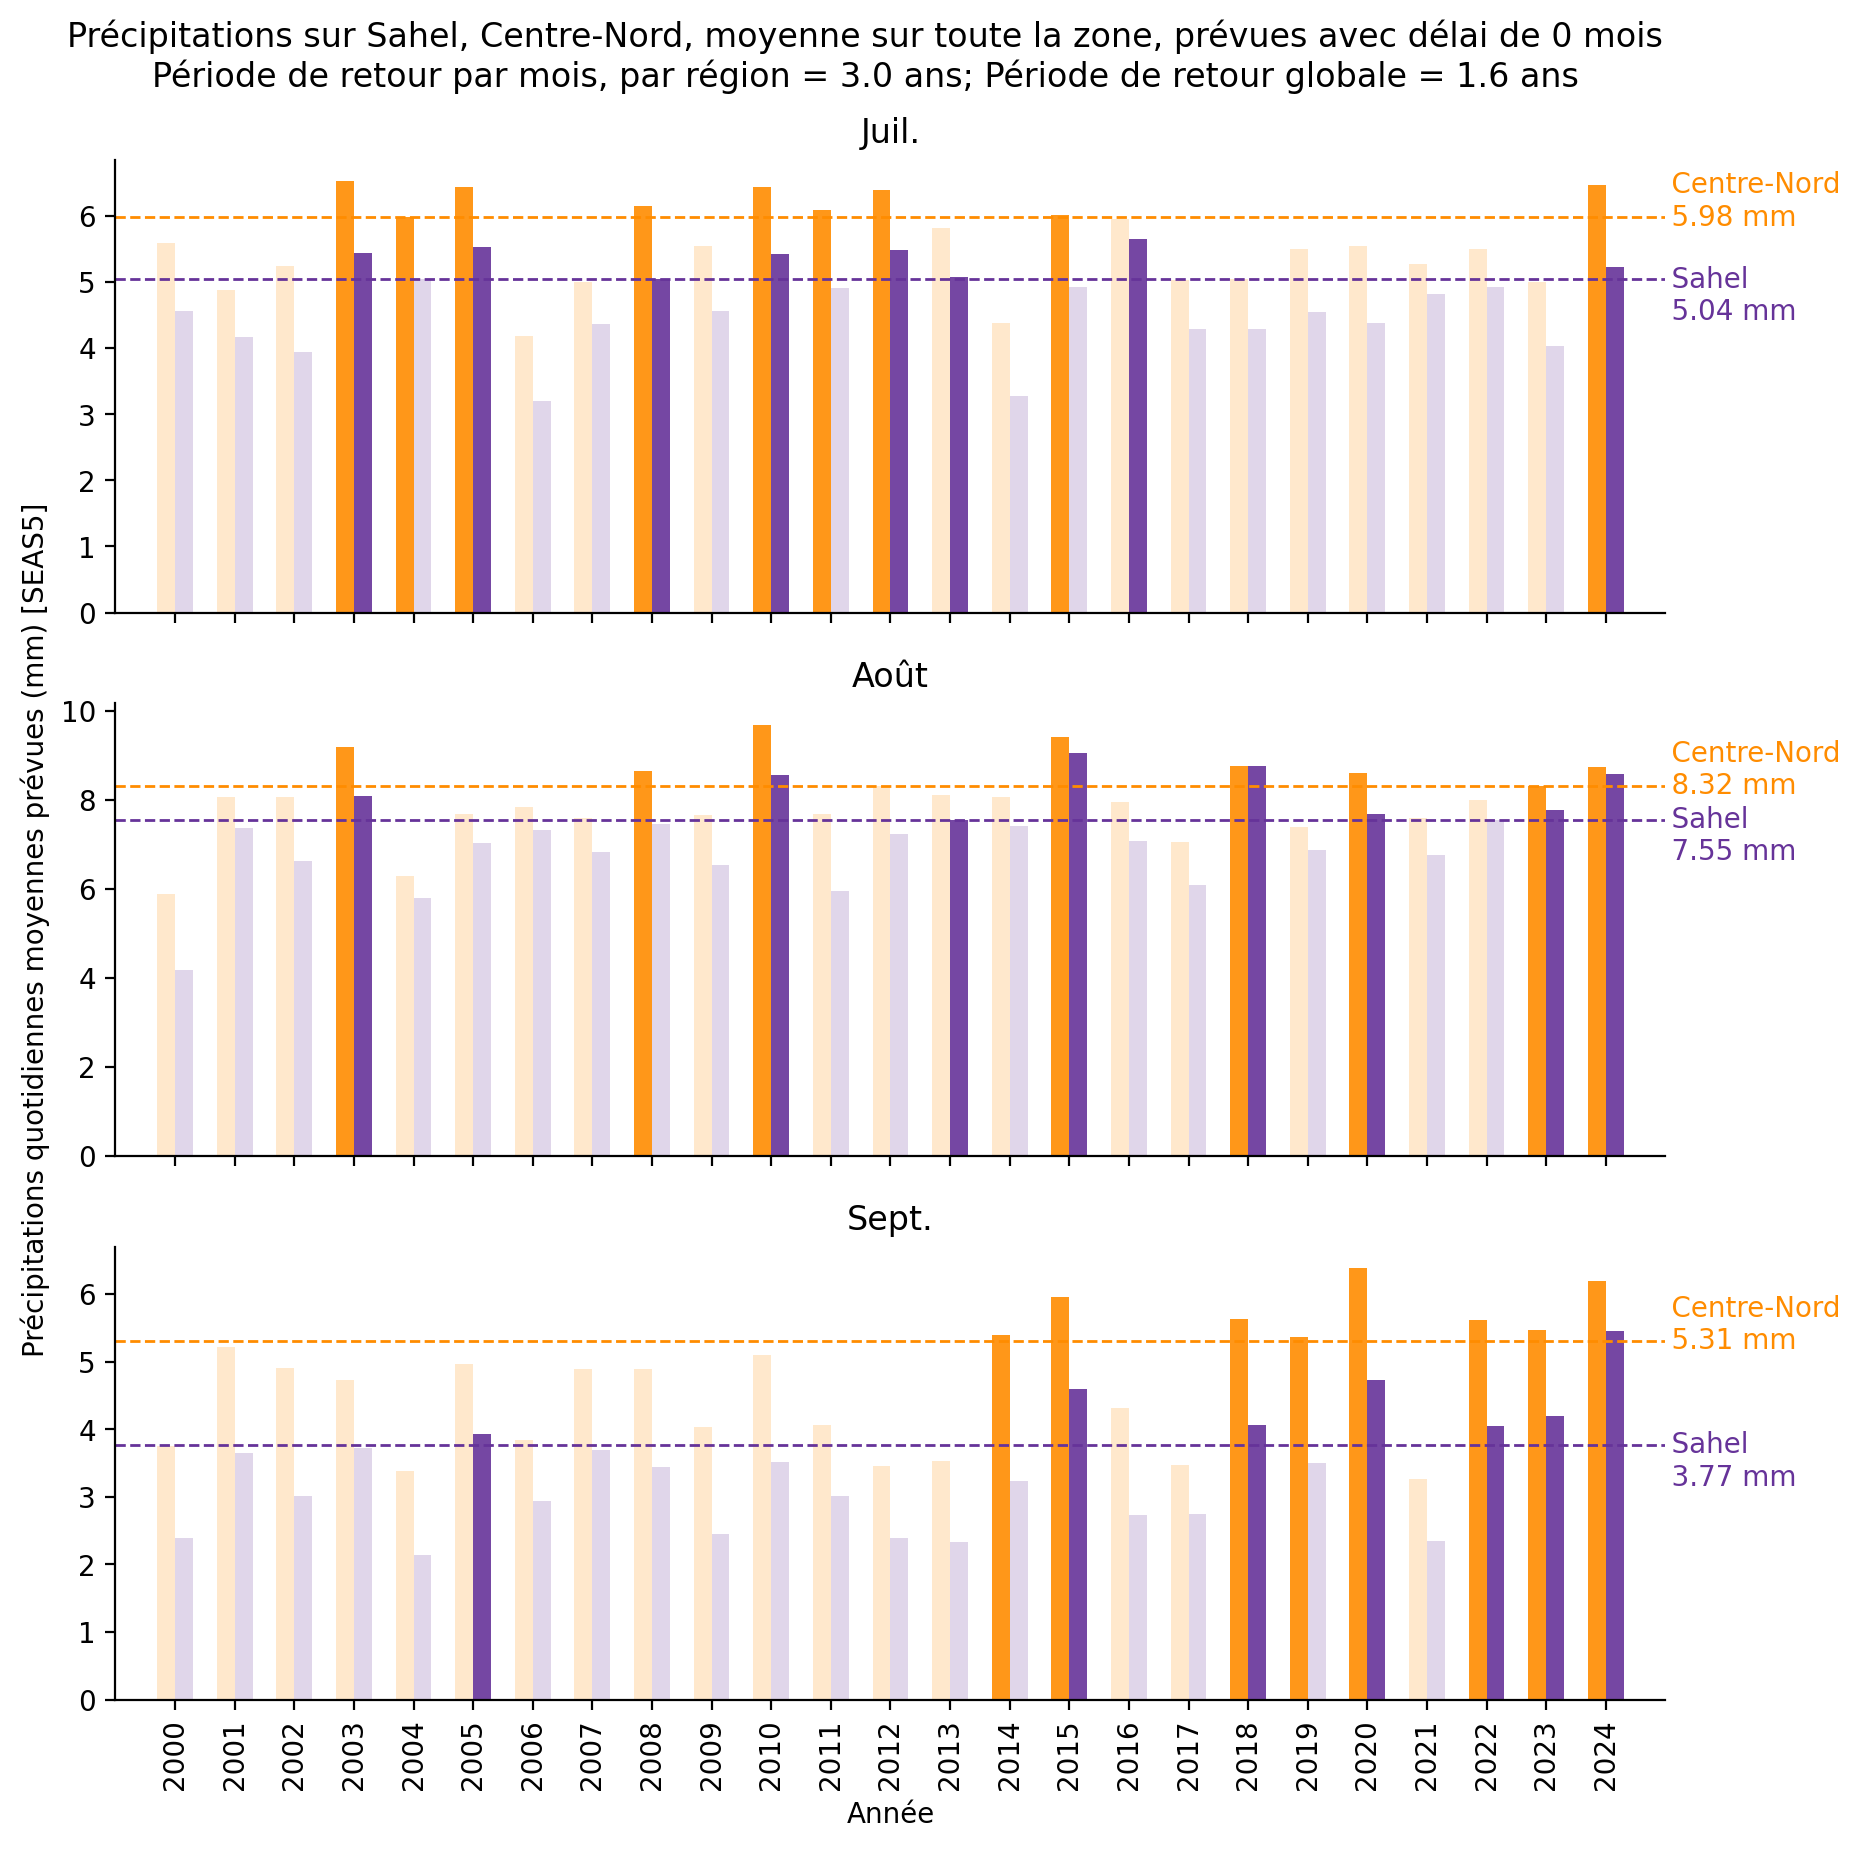

In [171]:
min_year = 2000

fig, axs = plt.subplots(nrows=3, figsize=(10, 10), sharex=True, dpi=200)

trig_colors = ["darkorange", "rebeccapurple"]
vas = ["bottom", "top"]

df_plot = df_seas5_season.copy()
df_plot["trig"] = False

triggered_years = []

dicts = []
for i, (month, group) in enumerate(df_plot.groupby("month")):
    group = group.sort_values("mean_rp").copy()
    ax = axs[i]

    for j, (name, name_group) in enumerate(group.groupby("name")):
        color = trig_colors[j]
        thresh = np.interp(rp_ind, name_group["mean_rp"], name_group["mean"])
        name_group["trig"] = name_group["mean"] >= thresh
        triggered_years.extend(name_group[name_group["trig"]]["year"])

        name_group_plot = name_group[
            name_group["year"] >= min_year
        ].sort_values("year")

        x = np.arange(len(name_group_plot.index))
        bar_width = 0.3
        values = name_group_plot["mean"]
        offset = (j - 0.5) * bar_width

        # Set alpha based on threshold comparison
        alphas = name_group_plot["trig"].apply(lambda v: 0.9 if v else 0.2)

        # Plot individual bars with varying alpha
        for xi, yi, alpha in zip(x, values, alphas):
            ax.bar(xi + offset, yi, width=bar_width, color=color, alpha=alpha)

        ax.axhline(thresh, color=color, linestyle="--", linewidth=1)
        annotation = f"    {name} \n    {thresh:.2f} mm"
        if j == 0:
            annotation = annotation + "\n"
        else:
            annotation = "\n" + annotation
        ax.annotate(
            annotation,
            (len(name_group_plot) - 0.5, thresh),
            va="center",
            color=color,
        )

    ax.set_xticks(x)
    ax.set_xlim((-1, len(name_group_plot)))
    ax.set_xticklabels(name_group_plot["year"], rotation=90)
    ax.set_title(FRENCH_MONTHS[calendar.month_abbr[month]].capitalize())

    if i == 1:
        ax.set_ylabel(
            "Précipitations quotidiennes moyennes prévues (mm) [SEAS5]"
        )

    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)

    dicts.append({"month": month, "thresh": thresh})

rp_com = (total_years + 1) / len(set(triggered_years))

axs[-1].set_xlabel("Année")

fig.suptitle(
    f"Précipitations sur {names_str}, moyenne sur toute la zone, prévues avec délai de 0 mois\n"
    f"Période de retour par mois, par région = {rp_ind:.1f} ans; Période de retour globale = {rp_com:.1f} ans",
    y=0.95,
)

## Current values

Just looking at the values from July 2025, since this is excluded from the plots above.

Looks like neither one triggered.

In [173]:
df_seas5_grouped[
    (df_seas5_grouped["valid_date"] == "2025-07-01")
    & (df_seas5_grouped["issued_date"] == "2025-07-01")
]

,name,pcode,valid_date,issued_date,mean
3723,Centre-Nord,BF49,2025-07-01,2025-07-01,5.721612
7468,Sahel,BF56,2025-07-01,2025-07-01,4.791461
